In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



Evaluating Model: KNN
  Run 1: Acc=0.8586, Features=23
  Features selected: [ 1  2  3  4  6  7 12 14 15 17 18 20 24 25 26 27 28 30 32 33 35 36 37]
  Run 2: Acc=0.8687, Features=20
  Features selected: [ 1  3  4  6  9 11 12 15 16 17 20 22 25 26 28 29 32 33 36 37]
  Run 3: Acc=0.8182, Features=16
  Features selected: [ 1  2  3  4  7 14 15 16 19 21 22 24 26 31 33 35]
  Run 4: Acc=0.8485, Features=12
  Features selected: [ 2  3  4  5 11 15 16 21 26 32 33 35]
  Run 5: Acc=0.8889, Features=19
  Features selected: [ 1  2  3  4  7 13 15 16 17 18 19 21 24 26 29 32 33 34 35]
  Run 6: Acc=0.8687, Features=16
  Features selected: [ 1  3  5 11 12 13 14 15 16 18 20 22 28 34 35 37]
  Run 7: Acc=0.8586, Features=17
  Features selected: [ 1  2  3  4  7  8  9 14 18 20 21 22 24 26 27 30 33]
  Run 8: Acc=0.8586, Features=20
  Features selected: [ 1  3  4  5  6  7  9 11 12 15 17 18 20 22 25 26 28 30 32 36]
  Run 9: Acc=0.8788, Features=20
  Features selected: [ 2  3  4  5  8 10 13 14 15 18 19 20 25 28 29 

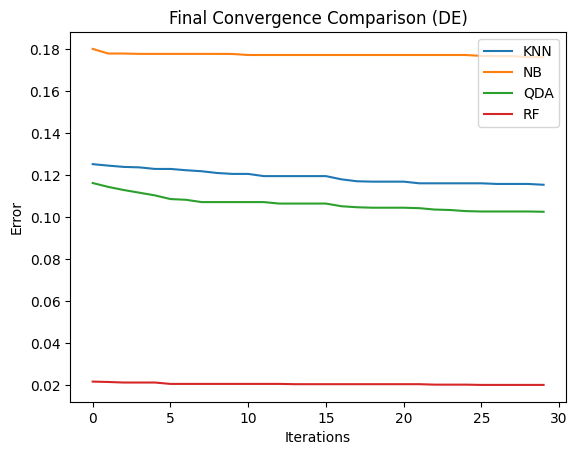


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 85.10%
Precision : 0.2557
Recall    : 0.0962
F1-Score  : 0.1252

Avg Execution Time : 5.4464 s
Avg Memory Used    : 0.0003 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  86.06%   0.4293  0.1231 0.1879      18.3    51.84%
   NB  84.04%   0.3511  0.2538 0.2938      16.5    56.58%
  QDA  84.34%   0.2383  0.0846 0.1238      25.2    33.68%
   RF  85.86%   0.0000  0.0000 0.0000      14.2    62.63%


In [ ]:
# @title
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore")

# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# =========================
# SEED
# =========================
np.random.seed(42)
random.seed(42)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-CM1.csv')

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x in ['Y', 1, True] else 0)

# =========================
# SPLIT
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

D = X_train.shape[1]

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20)
}

# =========================
# DE PARAMETERS
# =========================
NP = 10
CR = 0.9
F = 0.5
max_it = 30

# =========================
# FITNESS
# =========================
def fitness(individual, model):
    selected = np.where(individual == 1)[0]

    if len(selected) == 0:
        return 1.0

    try:
        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_train[:, selected])
        error = 1 - accuracy_score(y_train, pred)
    except:
        return 1.0

    penalty = 0.05 * (len(selected) / D)
    return error + penalty

# =========================
# INIT POPULATION
# =========================
def init_population():
    return np.random.randint(0, 2, (NP, D))

# =========================
# DE ALGORITHM
# =========================
def DE(model):

    pop = init_population()
    fit = np.array([fitness(ind, model) for ind in pop])

    convergence = []

    for _ in range(max_it):

        for i in range(NP):

            idxs = list(range(NP))
            idxs.remove(i)
            a, b, c = random.sample(idxs, 3)

            mutant = pop[a] + F * (pop[b] - pop[c])
            mutant = 1 / (1 + np.exp(-mutant))
            mutant = (mutant > np.random.rand(D)).astype(int)

            trial = pop[i].copy()

            for j in range(D):
                if random.random() < CR:
                    trial[j] = mutant[j]

            f_trial = fitness(trial, model)

            if f_trial < fit[i]:
                pop[i] = trial
                fit[i] = f_trial

        convergence.append(np.min(fit))

    best = pop[np.argmin(fit)]
    return np.where(best == 1)[0], convergence

# =========================
# MAIN LOOP
# =========================
Total_time = []
Total_memory = []

avg_acc_noFS = []
avg_prec_noFS = []
avg_rec_noFS = []
avg_f1_noFS = []

model_summaries = []

for name, model in models.items():

    print(f"\nEvaluating Model: {name}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024**2
        st = time.time()

        selected, curve = DE(model)

        et = time.time()
        mem_after = process.memory_info().rss / 1024**2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        if len(selected) == 0:
            selected = np.array([np.random.randint(0, D)])

        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_test[:, selected])

        acc = np.mean(pred == y_test)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)
        feat_list.append(len(selected))
        curves.append(curve)

        print(f"  Run {r}: Acc={acc:.4f}, Features={len(selected)}")
        print(f"  Features selected: {selected}")

    # 🔥 STORE CURVE
    model_curves[name] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model)
    clf_nofs.fit(X_train, y_train)
    pred_no = clf_nofs.predict(X_test)

    acc_no = np.mean(pred_no == y_test) * 100
    print(f"  Accuracy without FS: {acc_no:.2f}%")

    avg_acc_noFS.append(acc_no)
    avg_prec_noFS.append(precision_score(y_test, pred_no, zero_division=0))
    avg_rec_noFS.append(recall_score(y_test, pred_no, zero_division=0))
    avg_f1_noFS.append(f1_score(y_test, pred_no, zero_division=0))

    model_summaries.append({
        "Model": name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (DE)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print("\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(avg_acc_noFS):.2f}%")
print(f"Precision : {np.mean(avg_prec_noFS):.4f}")
print(f"Recall    : {np.mean(avg_rec_noFS):.4f}")
print(f"F1-Score  : {np.mean(avg_f1_noFS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7520, Features=6
  Features selected: [ 6 10 13 19 20 21]
  Run 2: Acc=0.7696, Features=10
  Features selected: [ 1  2  4  7  8 10 11 14 15 20]
  Run 3: Acc=0.7687, Features=8
  Features selected: [ 1  3  5  6 11 17 19 21]
  Run 4: Acc=0.7606, Features=8
  Features selected: [ 4  6 10 13 14 16 20 21]
  Run 5: Acc=0.7516, Features=6
  Features selected: [ 1  7  9 15 16 18]
  Run 6: Acc=0.7567, Features=8
  Features selected: [ 1  8  9 10 14 15 17 18]
  Run 7: Acc=0.7645, Features=7
  Features selected: [ 6  8  9 16 17 18 20]
  Run 8: Acc=0.7649, Features=9
  Features selected: [ 6  9 10 13 15 16 19 20 21]
  Run 9: Acc=0.7619, Features=12
  Features selected: [ 1  2  5  6  7  8 10 13 15 19 20 21]
  Run 10: Acc=0.7670, Features=7
  Features selected: [ 1  2  9 16 17 18 19]
  Accuracy without FS: 75.97%

Evaluating Model: NB
  Run 1: Acc=0.7824, Features=4
  Features selected: [ 4  8 11 14]
  Run 2: Acc=0.7786, Features=6
  Features selected: [ 3 14 18

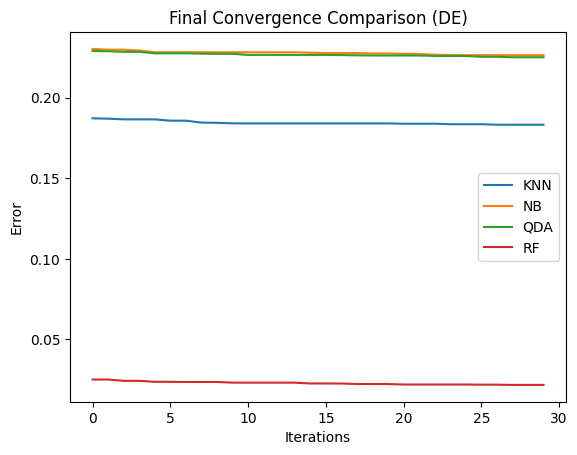


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 77.42%
Precision : 0.4420
Recall    : 0.1733
F1-Score  : 0.2468

Avg Execution Time : 56.0774 s
Avg Memory Used    : 0.2553 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  76.18%   0.4001  0.2193 0.2830       8.1    63.18%
   NB  77.81%   0.4511  0.1474 0.2210       6.4    70.91%
  QDA  77.97%   0.4501  0.1114 0.1782       5.9    73.18%
   RF  77.35%   0.4276  0.1524 0.2243       6.3    71.36%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore")

# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# =========================
# SEED
# =========================
np.random.seed(42)
random.seed(42)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-JM1.csv')

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x in ['Y', 1, True] else 0)

# =========================
# SPLIT
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

D = X_train.shape[1]

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20)
}

# =========================
# DE PARAMETERS
# =========================
NP = 10
CR = 0.9
F = 0.5
max_it = 30

# =========================
# FITNESS
# =========================
def fitness(individual, model):
    selected = np.where(individual == 1)[0]

    if len(selected) == 0:
        return 1.0

    try:
        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_train[:, selected])
        error = 1 - accuracy_score(y_train, pred)
    except:
        return 1.0

    penalty = 0.05 * (len(selected) / D)
    return error + penalty

# =========================
# INIT POPULATION
# =========================
def init_population():
    return np.random.randint(0, 2, (NP, D))

# =========================
# DE ALGORITHM
# =========================
def DE(model):

    pop = init_population()
    fit = np.array([fitness(ind, model) for ind in pop])

    convergence = []

    for _ in range(max_it):

        for i in range(NP):

            idxs = list(range(NP))
            idxs.remove(i)
            a, b, c = random.sample(idxs, 3)

            mutant = pop[a] + F * (pop[b] - pop[c])
            mutant = 1 / (1 + np.exp(-mutant))
            mutant = (mutant > np.random.rand(D)).astype(int)

            trial = pop[i].copy()

            for j in range(D):
                if random.random() < CR:
                    trial[j] = mutant[j]

            f_trial = fitness(trial, model)

            if f_trial < fit[i]:
                pop[i] = trial
                fit[i] = f_trial

        convergence.append(np.min(fit))

    best = pop[np.argmin(fit)]
    return np.where(best == 1)[0], convergence

# =========================
# MAIN LOOP
# =========================
Total_time = []
Total_memory = []

avg_acc_noFS = []
avg_prec_noFS = []
avg_rec_noFS = []
avg_f1_noFS = []

model_summaries = []

for name, model in models.items():

    print(f"\nEvaluating Model: {name}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024**2
        st = time.time()

        selected, curve = DE(model)

        et = time.time()
        mem_after = process.memory_info().rss / 1024**2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        if len(selected) == 0:
            selected = np.array([np.random.randint(0, D)])

        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_test[:, selected])

        acc = np.mean(pred == y_test)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)
        feat_list.append(len(selected))
        curves.append(curve)

        print(f"  Run {r}: Acc={acc:.4f}, Features={len(selected)}")
        print(f"  Features selected: {selected}")

    # 🔥 STORE CURVE
    model_curves[name] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model)
    clf_nofs.fit(X_train, y_train)
    pred_no = clf_nofs.predict(X_test)

    acc_no = np.mean(pred_no == y_test) * 100
    print(f"  Accuracy without FS: {acc_no:.2f}%")

    avg_acc_noFS.append(acc_no)
    avg_prec_noFS.append(precision_score(y_test, pred_no, zero_division=0))
    avg_rec_noFS.append(recall_score(y_test, pred_no, zero_division=0))
    avg_f1_noFS.append(f1_score(y_test, pred_no, zero_division=0))

    model_summaries.append({
        "Model": name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (DE)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print("\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(avg_acc_noFS):.2f}%")
print(f"Precision : {np.mean(avg_prec_noFS):.4f}")
print(f"Recall    : {np.mean(avg_rec_noFS):.4f}")
print(f"F1-Score  : {np.mean(avg_f1_noFS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7099, Features=10
  Features selected: [ 4  5  9 10 13 14 15 19 20 21]
  Run 2: Acc=0.7324, Features=10
  Features selected: [ 3  4  9 10 11 13 16 18 20 21]
  Run 3: Acc=0.7070, Features=8
  Features selected: [ 4  5  9 10 13 14 18 20]
  Run 4: Acc=0.7070, Features=8
  Features selected: [ 4  6  7 11 12 13 20 21]
  Run 5: Acc=0.7070, Features=10
  Features selected: [ 4  5  6  7  8  9 11 16 17 19]
  Run 6: Acc=0.7268, Features=10
  Features selected: [ 2  3  4  9 10 11 14 17 20 21]
  Run 7: Acc=0.7127, Features=8
  Features selected: [ 2  3  4  8  9 10 14 17]
  Run 8: Acc=0.7239, Features=10
  Features selected: [ 4  5  7  9 12 14 15 17 20 21]
  Run 9: Acc=0.7352, Features=11
  Features selected: [ 2  3  4  9 10 11 13 18 19 20 21]
  Run 10: Acc=0.7268, Features=12
  Features selected: [ 3  4  5  6  7  8  9 10 11 17 18 20]
  Accuracy without FS: 69.58%

Evaluating Model: NB
  Run 1: Acc=0.7521, Features=8
  Features selected: [ 0  1  2  3 11 12 15 1

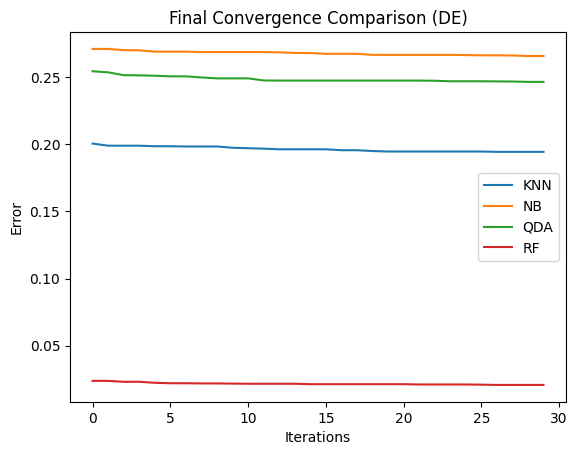


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 72.75%
Precision : 0.4703
Recall    : 0.2580
F1-Score  : 0.3329

Avg Execution Time : 9.1210 s
Avg Memory Used    : 0.0035 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  71.89%   0.4428  0.2351 0.3067       9.7    55.91%
   NB  73.52%   0.5002  0.2298 0.3147       8.5    61.36%
  QDA  74.45%   0.5432  0.2223 0.3152       9.1    58.64%
   RF  71.44%   0.4291  0.2383 0.3060       7.3    66.82%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore")

# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# =========================
# SEED
# =========================
np.random.seed(42)
random.seed(42)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-KC1.csv')

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x in ['Y', 1, True] else 0)

# =========================
# SPLIT
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

D = X_train.shape[1]

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20)
}

# =========================
# DE PARAMETERS
# =========================
NP = 10
CR = 0.9
F = 0.5
max_it = 30

# =========================
# FITNESS
# =========================
def fitness(individual, model):
    selected = np.where(individual == 1)[0]

    if len(selected) == 0:
        return 1.0

    try:
        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_train[:, selected])
        error = 1 - accuracy_score(y_train, pred)
    except:
        return 1.0

    penalty = 0.05 * (len(selected) / D)
    return error + penalty

# =========================
# INIT POPULATION
# =========================
def init_population():
    return np.random.randint(0, 2, (NP, D))

# =========================
# DE ALGORITHM
# =========================
def DE(model):

    pop = init_population()
    fit = np.array([fitness(ind, model) for ind in pop])

    convergence = []

    for _ in range(max_it):

        for i in range(NP):

            idxs = list(range(NP))
            idxs.remove(i)
            a, b, c = random.sample(idxs, 3)

            mutant = pop[a] + F * (pop[b] - pop[c])
            mutant = 1 / (1 + np.exp(-mutant))
            mutant = (mutant > np.random.rand(D)).astype(int)

            trial = pop[i].copy()

            for j in range(D):
                if random.random() < CR:
                    trial[j] = mutant[j]

            f_trial = fitness(trial, model)

            if f_trial < fit[i]:
                pop[i] = trial
                fit[i] = f_trial

        convergence.append(np.min(fit))

    best = pop[np.argmin(fit)]
    return np.where(best == 1)[0], convergence

# =========================
# MAIN LOOP
# =========================
Total_time = []
Total_memory = []

avg_acc_noFS = []
avg_prec_noFS = []
avg_rec_noFS = []
avg_f1_noFS = []

model_summaries = []

for name, model in models.items():

    print(f"\nEvaluating Model: {name}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024**2
        st = time.time()

        selected, curve = DE(model)

        et = time.time()
        mem_after = process.memory_info().rss / 1024**2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        if len(selected) == 0:
            selected = np.array([np.random.randint(0, D)])

        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_test[:, selected])

        acc = np.mean(pred == y_test)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)
        feat_list.append(len(selected))
        curves.append(curve)

        print(f"  Run {r}: Acc={acc:.4f}, Features={len(selected)}")
        print(f"  Features selected: {selected}")

    # 🔥 STORE CURVE
    model_curves[name] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model)
    clf_nofs.fit(X_train, y_train)
    pred_no = clf_nofs.predict(X_test)

    acc_no = np.mean(pred_no == y_test) * 100
    print(f"  Accuracy without FS: {acc_no:.2f}%")

    avg_acc_noFS.append(acc_no)
    avg_prec_noFS.append(precision_score(y_test, pred_no, zero_division=0))
    avg_rec_noFS.append(recall_score(y_test, pred_no, zero_division=0))
    avg_f1_noFS.append(f1_score(y_test, pred_no, zero_division=0))

    model_summaries.append({
        "Model": name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (DE)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print("\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(avg_acc_noFS):.2f}%")
print(f"Precision : {np.mean(avg_prec_noFS):.4f}")
print(f"Recall    : {np.mean(avg_rec_noFS):.4f}")
print(f"F1-Score  : {np.mean(avg_f1_noFS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7627, Features=24
  Features selected: [ 0  1  2  3  5  6  7 15 16 20 21 22 24 26 27 28 31 32 33 34 35 36 37 39]
  Run 2: Acc=0.7288, Features=22
  Features selected: [ 2  5  7 12 14 15 18 19 20 22 23 24 25 26 30 31 33 34 35 36 37 38]
  Run 3: Acc=0.7458, Features=20
  Features selected: [ 1  2  5  6  7 10 11 12 13 15 19 22 23 25 27 30 31 32 35 37]
  Run 4: Acc=0.7966, Features=18
  Features selected: [ 1  4  5  6  7 10 12 13 16 18 21 24 28 30 31 33 34 36]
  Run 5: Acc=0.7966, Features=19
  Features selected: [ 2  3  4  5 12 13 14 16 17 19 22 24 26 32 35 36 37 38 39]
  Run 6: Acc=0.7288, Features=22
  Features selected: [ 0  2  3  5  6  7  8  9 12 13 16 17 19 20 22 25 27 29 32 34 36 38]
  Run 7: Acc=0.8136, Features=24
  Features selected: [ 0  1  4  5  7  9 11 14 15 18 19 21 22 24 25 27 28 29 31 32 34 35 36 39]
  Run 8: Acc=0.8136, Features=18
  Features selected: [ 1  2  4  7 11 12 18 21 23 24 25 28 32 33 35 36 37 38]
  Run 9: Acc=0.7458, Feature

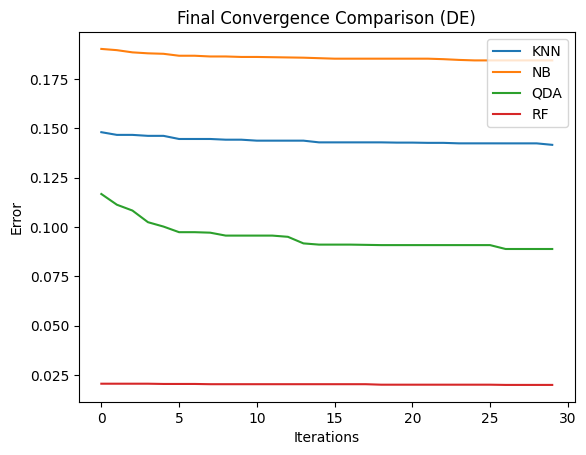


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 79.24%
Precision : 0.4437
Recall    : 0.1364
F1-Score  : 0.1831

Avg Execution Time : 4.6550 s
Avg Memory Used    : 0.0021 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  77.29%   0.3156  0.1636 0.2092      20.9    47.75%
   NB  76.78%   0.3000  0.1818 0.2261      18.4    54.00%
  QDA  81.53%   0.5362  0.2455 0.3280      24.3    39.25%
   RF  77.63%   0.2033  0.0455 0.0695      16.0    60.00%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore")

# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# =========================
# SEED
# =========================
np.random.seed(42)
random.seed(42)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-KC3.csv')

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x in ['Y', 1, True] else 0)

# =========================
# SPLIT
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

D = X_train.shape[1]

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20)
}

# =========================
# DE PARAMETERS
# =========================
NP = 10
CR = 0.9
F = 0.5
max_it = 30

# =========================
# FITNESS
# =========================
def fitness(individual, model):
    selected = np.where(individual == 1)[0]

    if len(selected) == 0:
        return 1.0

    try:
        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_train[:, selected])
        error = 1 - accuracy_score(y_train, pred)
    except:
        return 1.0

    penalty = 0.05 * (len(selected) / D)
    return error + penalty

# =========================
# INIT POPULATION
# =========================
def init_population():
    return np.random.randint(0, 2, (NP, D))

# =========================
# DE ALGORITHM
# =========================
def DE(model):

    pop = init_population()
    fit = np.array([fitness(ind, model) for ind in pop])

    convergence = []

    for _ in range(max_it):

        for i in range(NP):

            idxs = list(range(NP))
            idxs.remove(i)
            a, b, c = random.sample(idxs, 3)

            mutant = pop[a] + F * (pop[b] - pop[c])
            mutant = 1 / (1 + np.exp(-mutant))
            mutant = (mutant > np.random.rand(D)).astype(int)

            trial = pop[i].copy()

            for j in range(D):
                if random.random() < CR:
                    trial[j] = mutant[j]

            f_trial = fitness(trial, model)

            if f_trial < fit[i]:
                pop[i] = trial
                fit[i] = f_trial

        convergence.append(np.min(fit))

    best = pop[np.argmin(fit)]
    return np.where(best == 1)[0], convergence

# =========================
# MAIN LOOP
# =========================
Total_time = []
Total_memory = []

avg_acc_noFS = []
avg_prec_noFS = []
avg_rec_noFS = []
avg_f1_noFS = []

model_summaries = []

for name, model in models.items():

    print(f"\nEvaluating Model: {name}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024**2
        st = time.time()

        selected, curve = DE(model)

        et = time.time()
        mem_after = process.memory_info().rss / 1024**2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        if len(selected) == 0:
            selected = np.array([np.random.randint(0, D)])

        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_test[:, selected])

        acc = np.mean(pred == y_test)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)
        feat_list.append(len(selected))
        curves.append(curve)

        print(f"  Run {r}: Acc={acc:.4f}, Features={len(selected)}")
        print(f"  Features selected: {selected}")

    # 🔥 STORE CURVE
    model_curves[name] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model)
    clf_nofs.fit(X_train, y_train)
    pred_no = clf_nofs.predict(X_test)

    acc_no = np.mean(pred_no == y_test) * 100
    print(f"  Accuracy without FS: {acc_no:.2f}%")

    avg_acc_noFS.append(acc_no)
    avg_prec_noFS.append(precision_score(y_test, pred_no, zero_division=0))
    avg_rec_noFS.append(recall_score(y_test, pred_no, zero_division=0))
    avg_f1_noFS.append(f1_score(y_test, pred_no, zero_division=0))

    model_summaries.append({
        "Model": name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (DE)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print("\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(avg_acc_noFS):.2f}%")
print(f"Precision : {np.mean(avg_prec_noFS):.4f}")
print(f"Recall    : {np.mean(avg_rec_noFS):.4f}")
print(f"F1-Score  : {np.mean(avg_f1_noFS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.9765, Features=14
  Features selected: [ 1  3  6  7  9 10 12 14 19 25 29 32 34 37]
  Run 2: Acc=0.9782, Features=15
  Features selected: [ 0  4  5  6  9 13 16 18 20 21 24 26 31 32 38]
  Run 3: Acc=0.9765, Features=14
  Features selected: [ 0  1  3  5  6  8 12 17 18 25 32 33 35 37]
  Run 4: Acc=0.9765, Features=18
  Features selected: [ 0  2  3  4  8 10 13 15 16 18 21 23 24 26 28 30 32 36]
  Run 5: Acc=0.9732, Features=15
  Features selected: [ 4  5  9 13 15 17 18 21 23 25 28 29 35 36 37]
  Run 6: Acc=0.9782, Features=15
  Features selected: [ 0  4  5  6 10 11 13 16 18 26 28 29 30 34 35]
  Run 7: Acc=0.9732, Features=13
  Features selected: [ 1  6  7  9 12 13 18 20 25 28 31 33 35]
  Run 8: Acc=0.9732, Features=14
  Features selected: [ 1  4  5  6  9 15 16 17 24 26 32 33 34 38]
  Run 9: Acc=0.9765, Features=15
  Features selected: [ 0  4  6 13 15 17 19 20 21 24 27 28 29 33 36]
  Run 10: Acc=0.9749, Features=16
  Features selected: [ 0  1  2  3  4  6 

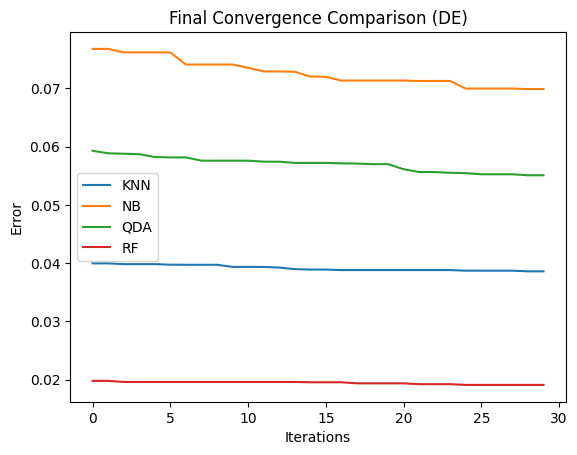


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 95.39%
Precision : 0.1773
Recall    : 0.0714
F1-Score  : 0.0726

Avg Execution Time : 9.7885 s
Avg Memory Used    : -0.0655 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  97.57%   0.3000  0.0357 0.0614      14.9    61.79%
   NB  94.30%   0.0489  0.0786 0.0588      15.6    60.00%
  QDA  95.06%   0.0383  0.0571 0.0450      16.5    57.69%
   RF  97.34%   0.2025  0.0714 0.1030      13.7    64.87%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore")

# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# =========================
# SEED
# =========================
np.random.seed(42)
random.seed(42)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-MC1.csv')

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x in ['Y', 1, True] else 0)

# =========================
# SPLIT
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

D = X_train.shape[1]

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20)
}

# =========================
# DE PARAMETERS
# =========================
NP = 10
CR = 0.9
F = 0.5
max_it = 30

# =========================
# FITNESS
# =========================
def fitness(individual, model):
    selected = np.where(individual == 1)[0]

    if len(selected) == 0:
        return 1.0

    try:
        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_train[:, selected])
        error = 1 - accuracy_score(y_train, pred)
    except:
        return 1.0

    penalty = 0.05 * (len(selected) / D)
    return error + penalty

# =========================
# INIT POPULATION
# =========================
def init_population():
    return np.random.randint(0, 2, (NP, D))

# =========================
# DE ALGORITHM
# =========================
def DE(model):

    pop = init_population()
    fit = np.array([fitness(ind, model) for ind in pop])

    convergence = []

    for _ in range(max_it):

        for i in range(NP):

            idxs = list(range(NP))
            idxs.remove(i)
            a, b, c = random.sample(idxs, 3)

            mutant = pop[a] + F * (pop[b] - pop[c])
            mutant = 1 / (1 + np.exp(-mutant))
            mutant = (mutant > np.random.rand(D)).astype(int)

            trial = pop[i].copy()

            for j in range(D):
                if random.random() < CR:
                    trial[j] = mutant[j]

            f_trial = fitness(trial, model)

            if f_trial < fit[i]:
                pop[i] = trial
                fit[i] = f_trial

        convergence.append(np.min(fit))

    best = pop[np.argmin(fit)]
    return np.where(best == 1)[0], convergence

# =========================
# MAIN LOOP
# =========================
Total_time = []
Total_memory = []

avg_acc_noFS = []
avg_prec_noFS = []
avg_rec_noFS = []
avg_f1_noFS = []

model_summaries = []

for name, model in models.items():

    print(f"\nEvaluating Model: {name}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024**2
        st = time.time()

        selected, curve = DE(model)

        et = time.time()
        mem_after = process.memory_info().rss / 1024**2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        if len(selected) == 0:
            selected = np.array([np.random.randint(0, D)])

        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_test[:, selected])

        acc = np.mean(pred == y_test)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)
        feat_list.append(len(selected))
        curves.append(curve)

        print(f"  Run {r}: Acc={acc:.4f}, Features={len(selected)}")
        print(f"  Features selected: {selected}")

    # 🔥 STORE CURVE
    model_curves[name] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model)
    clf_nofs.fit(X_train, y_train)
    pred_no = clf_nofs.predict(X_test)

    acc_no = np.mean(pred_no == y_test) * 100
    print(f"  Accuracy without FS: {acc_no:.2f}%")

    avg_acc_noFS.append(acc_no)
    avg_prec_noFS.append(precision_score(y_test, pred_no, zero_division=0))
    avg_rec_noFS.append(recall_score(y_test, pred_no, zero_division=0))
    avg_f1_noFS.append(f1_score(y_test, pred_no, zero_division=0))

    model_summaries.append({
        "Model": name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (DE)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print("\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(avg_acc_noFS):.2f}%")
print(f"Precision : {np.mean(avg_prec_noFS):.4f}")
print(f"Recall    : {np.mean(avg_rec_noFS):.4f}")
print(f"F1-Score  : {np.mean(avg_f1_noFS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.6316, Features=18
  Features selected: [ 6  7  9 13 14 15 16 17 19 20 25 28 29 30 31 33 36 38]
  Run 2: Acc=0.6579, Features=21
  Features selected: [ 1  2  3  5  6  7  8 11 12 13 16 18 20 21 25 26 29 31 33 38 39]
  Run 3: Acc=0.7105, Features=19
  Features selected: [ 1  2  4 12 16 20 21 22 24 25 26 27 30 31 32 34 37 38 39]
  Run 4: Acc=0.6579, Features=25
  Features selected: [ 1  2  3  4  5  7  8  9 10 13 15 17 18 21 23 24 25 26 29 32 33 34 35 37
 38]
  Run 5: Acc=0.5789, Features=23
  Features selected: [ 1  4  6  7  9 11 16 19 20 22 23 24 25 26 28 29 30 31 33 36 37 38 39]
  Run 6: Acc=0.5789, Features=27
  Features selected: [ 1  4  6  7  9 11 12 13 14 15 16 20 21 22 23 26 27 28 29 31 32 33 34 35
 37 38 39]
  Run 7: Acc=0.6842, Features=25
  Features selected: [ 1  3  4  8 11 12 13 16 20 21 22 24 25 26 27 29 30 31 32 33 34 35 37 38
 39]
  Run 8: Acc=0.6842, Features=20
  Features selected: [ 0  2  4  6 14 17 19 21 22 23 24 25 26 27 29 33 35 36

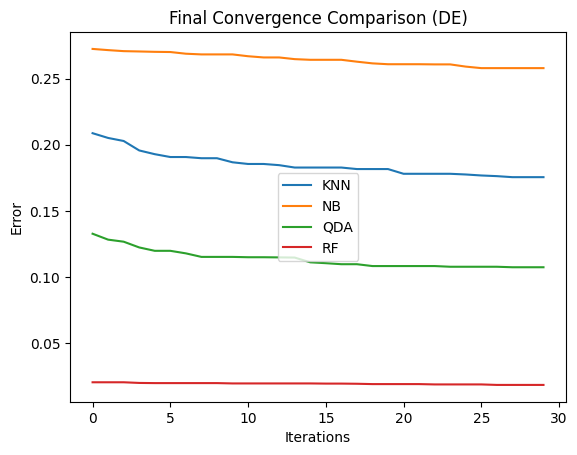


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 71.71%
Precision : 0.6940
Recall    : 0.3269
F1-Score  : 0.4427

Avg Execution Time : 4.3648 s
Avg Memory Used    : 0.0006 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  63.95%   0.4652  0.3385 0.3897      21.8    45.50%
   NB  72.63%   0.6851  0.3769 0.4855      20.6    48.50%
  QDA  72.11%   0.6293  0.4538 0.5262      27.1    32.25%
   RF  65.53%   0.5227  0.3538 0.4124      14.8    63.00%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore")

# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# =========================
# SEED
# =========================
np.random.seed(42)
random.seed(42)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-MC2.csv')

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x in ['Y', 1, True] else 0)

# =========================
# SPLIT
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

D = X_train.shape[1]

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20)
}

# =========================
# DE PARAMETERS
# =========================
NP = 10
CR = 0.9
F = 0.5
max_it = 30

# =========================
# FITNESS
# =========================
def fitness(individual, model):
    selected = np.where(individual == 1)[0]

    if len(selected) == 0:
        return 1.0

    try:
        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_train[:, selected])
        error = 1 - accuracy_score(y_train, pred)
    except:
        return 1.0

    penalty = 0.05 * (len(selected) / D)
    return error + penalty

# =========================
# INIT POPULATION
# =========================
def init_population():
    return np.random.randint(0, 2, (NP, D))

# =========================
# DE ALGORITHM
# =========================
def DE(model):

    pop = init_population()
    fit = np.array([fitness(ind, model) for ind in pop])

    convergence = []

    for _ in range(max_it):

        for i in range(NP):

            idxs = list(range(NP))
            idxs.remove(i)
            a, b, c = random.sample(idxs, 3)

            mutant = pop[a] + F * (pop[b] - pop[c])
            mutant = 1 / (1 + np.exp(-mutant))
            mutant = (mutant > np.random.rand(D)).astype(int)

            trial = pop[i].copy()

            for j in range(D):
                if random.random() < CR:
                    trial[j] = mutant[j]

            f_trial = fitness(trial, model)

            if f_trial < fit[i]:
                pop[i] = trial
                fit[i] = f_trial

        convergence.append(np.min(fit))

    best = pop[np.argmin(fit)]
    return np.where(best == 1)[0], convergence

# =========================
# MAIN LOOP
# =========================
Total_time = []
Total_memory = []

avg_acc_noFS = []
avg_prec_noFS = []
avg_rec_noFS = []
avg_f1_noFS = []

model_summaries = []

for name, model in models.items():

    print(f"\nEvaluating Model: {name}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024**2
        st = time.time()

        selected, curve = DE(model)

        et = time.time()
        mem_after = process.memory_info().rss / 1024**2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        if len(selected) == 0:
            selected = np.array([np.random.randint(0, D)])

        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_test[:, selected])

        acc = np.mean(pred == y_test)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)
        feat_list.append(len(selected))
        curves.append(curve)

        print(f"  Run {r}: Acc={acc:.4f}, Features={len(selected)}")
        print(f"  Features selected: {selected}")

    # 🔥 STORE CURVE
    model_curves[name] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model)
    clf_nofs.fit(X_train, y_train)
    pred_no = clf_nofs.predict(X_test)

    acc_no = np.mean(pred_no == y_test) * 100
    print(f"  Accuracy without FS: {acc_no:.2f}%")

    avg_acc_noFS.append(acc_no)
    avg_prec_noFS.append(precision_score(y_test, pred_no, zero_division=0))
    avg_rec_noFS.append(recall_score(y_test, pred_no, zero_division=0))
    avg_f1_noFS.append(f1_score(y_test, pred_no, zero_division=0))

    model_summaries.append({
        "Model": name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (DE)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print("\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(avg_acc_noFS):.2f}%")
print(f"Precision : {np.mean(avg_prec_noFS):.4f}")
print(f"Recall    : {np.mean(avg_rec_noFS):.4f}")
print(f"F1-Score  : {np.mean(avg_f1_noFS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.8553, Features=21
  Features selected: [ 2  3  5  6  7 12 14 15 17 18 20 24 25 27 28 30 32 33 35 36 37]
  Run 2: Acc=0.8816, Features=20
  Features selected: [ 1  2  4  6  7  8  9 10 13 15 18 21 22 28 29 30 31 32 33 36]
  Run 3: Acc=0.8947, Features=16
  Features selected: [ 2  3  5  6  7  8 10 12 21 26 27 28 30 31 32 35]
  Run 4: Acc=0.8816, Features=20
  Features selected: [ 3  4  5  6  8 11 12 17 18 21 22 24 26 27 28 32 33 34 36 37]
  Run 5: Acc=0.8816, Features=20
  Features selected: [ 1  2  3  4  5  8  9 10 12 17 18 20 21 23 24 27 28 29 34 37]
  Run 6: Acc=0.8553, Features=20
  Features selected: [ 0  1  3  4  5  6  8  9 10 11 12 14 15 17 25 26 27 28 33 35]
  Run 7: Acc=0.8816, Features=16
  Features selected: [ 2  3  5  6  9 10 12 13 14 17 18 23 24 29 30 32]
  Run 8: Acc=0.8947, Features=21
  Features selected: [ 5  6  7  8  9 12 13 18 19 20 21 24 26 27 28 29 30 33 34 35 37]
  Run 9: Acc=0.8947, Features=20
  Features selected: [ 2  3  4  5 

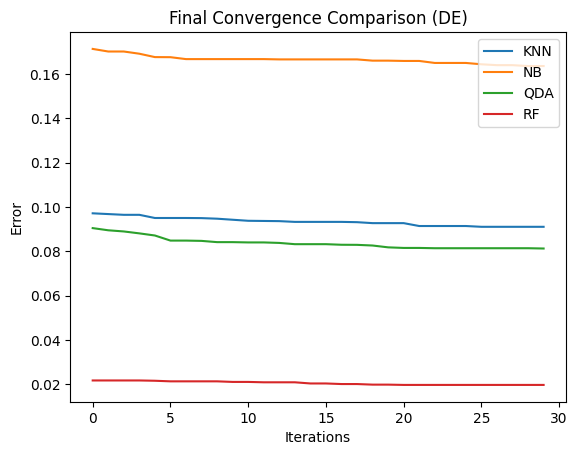


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 83.22%
Precision : 0.1895
Recall    : 0.2812
F1-Score  : 0.2148

Avg Execution Time : 4.6441 s
Avg Memory Used    : 0.0004 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  87.89%   0.4023  0.3500 0.3707      19.0    50.00%
   NB  77.89%   0.2671  0.6250 0.3739      17.9    52.89%
  QDA  87.63%   0.4470  0.6000 0.5091      21.0    44.74%
   RF  87.11%   0.4038  0.3250 0.3465      15.0    60.53%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore")

# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# =========================
# SEED
# =========================
np.random.seed(42)
random.seed(42)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-MW1.csv')

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x in ['Y', 1, True] else 0)

# =========================
# SPLIT
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

D = X_train.shape[1]

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20)
}

# =========================
# DE PARAMETERS
# =========================
NP = 10
CR = 0.9
F = 0.5
max_it = 30

# =========================
# FITNESS
# =========================
def fitness(individual, model):
    selected = np.where(individual == 1)[0]

    if len(selected) == 0:
        return 1.0

    try:
        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_train[:, selected])
        error = 1 - accuracy_score(y_train, pred)
    except:
        return 1.0

    penalty = 0.05 * (len(selected) / D)
    return error + penalty

# =========================
# INIT POPULATION
# =========================
def init_population():
    return np.random.randint(0, 2, (NP, D))

# =========================
# DE ALGORITHM
# =========================
def DE(model):

    pop = init_population()
    fit = np.array([fitness(ind, model) for ind in pop])

    convergence = []

    for _ in range(max_it):

        for i in range(NP):

            idxs = list(range(NP))
            idxs.remove(i)
            a, b, c = random.sample(idxs, 3)

            mutant = pop[a] + F * (pop[b] - pop[c])
            mutant = 1 / (1 + np.exp(-mutant))
            mutant = (mutant > np.random.rand(D)).astype(int)

            trial = pop[i].copy()

            for j in range(D):
                if random.random() < CR:
                    trial[j] = mutant[j]

            f_trial = fitness(trial, model)

            if f_trial < fit[i]:
                pop[i] = trial
                fit[i] = f_trial

        convergence.append(np.min(fit))

    best = pop[np.argmin(fit)]
    return np.where(best == 1)[0], convergence

# =========================
# MAIN LOOP
# =========================
Total_time = []
Total_memory = []

avg_acc_noFS = []
avg_prec_noFS = []
avg_rec_noFS = []
avg_f1_noFS = []

model_summaries = []

for name, model in models.items():

    print(f"\nEvaluating Model: {name}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024**2
        st = time.time()

        selected, curve = DE(model)

        et = time.time()
        mem_after = process.memory_info().rss / 1024**2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        if len(selected) == 0:
            selected = np.array([np.random.randint(0, D)])

        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_test[:, selected])

        acc = np.mean(pred == y_test)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)
        feat_list.append(len(selected))
        curves.append(curve)

        print(f"  Run {r}: Acc={acc:.4f}, Features={len(selected)}")
        print(f"  Features selected: {selected}")

    # 🔥 STORE CURVE
    model_curves[name] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model)
    clf_nofs.fit(X_train, y_train)
    pred_no = clf_nofs.predict(X_test)

    acc_no = np.mean(pred_no == y_test) * 100
    print(f"  Accuracy without FS: {acc_no:.2f}%")

    avg_acc_noFS.append(acc_no)
    avg_prec_noFS.append(precision_score(y_test, pred_no, zero_division=0))
    avg_rec_noFS.append(recall_score(y_test, pred_no, zero_division=0))
    avg_f1_noFS.append(f1_score(y_test, pred_no, zero_division=0))

    model_summaries.append({
        "Model": name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (DE)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print("\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(avg_acc_noFS):.2f}%")
print(f"Precision : {np.mean(avg_prec_noFS):.4f}")
print(f"Recall    : {np.mean(avg_rec_noFS):.4f}")
print(f"F1-Score  : {np.mean(avg_f1_noFS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.9009, Features=15
  Features selected: [ 3  5  7 10 11 12 14 17 18 21 22 23 30 34 37]
  Run 2: Acc=0.9198, Features=18
  Features selected: [ 0  3  9 10 12 13 15 17 18 23 25 27 30 32 33 35 36 37]
  Run 3: Acc=0.9057, Features=19
  Features selected: [ 0  1  2  3  4  6 10 11 12 13 15 21 24 26 28 30 33 34 36]
  Run 4: Acc=0.9057, Features=23
  Features selected: [ 1  3  4  5  6  7 10 12 14 15 17 19 23 24 26 27 30 32 33 34 35 36 37]
  Run 5: Acc=0.9009, Features=16
  Features selected: [ 0  1  2  3  4  9 13 16 17 18 21 26 28 30 34 36]
  Run 6: Acc=0.9057, Features=14
  Features selected: [ 4  6 13 14 18 21 23 26 29 30 31 35 36 37]
  Run 7: Acc=0.8915, Features=20
  Features selected: [ 2  3  4  7  8 10 11 12 14 15 17 19 21 27 30 31 33 34 35 37]
  Run 8: Acc=0.9104, Features=18
  Features selected: [ 2  4  7 11 13 14 15 17 20 21 22 23 24 26 31 33 34 36]
  Run 9: Acc=0.9009, Features=11
  Features selected: [ 3  6  7  8 10 11 20 33 34 35 37]
  Run 10: A

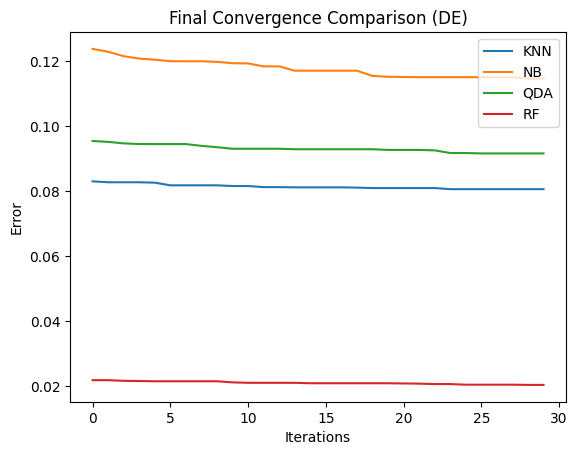


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 89.62%
Precision : 0.3854
Recall    : 0.2083
F1-Score  : 0.2430

Avg Execution Time : 6.2530 s
Avg Memory Used    : 0.0023 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  90.52%   0.3692  0.1167 0.1660      17.3    54.47%
   NB  90.66%   0.4308  0.2889 0.3446      16.3    57.11%
  QDA  89.95%   0.3482  0.1944 0.2474      16.7    56.05%
   RF  91.89%   0.6333  0.1556 0.2426      14.0    63.16%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore")

# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# =========================
# SEED
# =========================
np.random.seed(42)
random.seed(42)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-PC1.csv')

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x in ['Y', 1, True] else 0)

# =========================
# SPLIT
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

D = X_train.shape[1]

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20)
}

# =========================
# DE PARAMETERS
# =========================
NP = 10
CR = 0.9
F = 0.5
max_it = 30

# =========================
# FITNESS
# =========================
def fitness(individual, model):
    selected = np.where(individual == 1)[0]

    if len(selected) == 0:
        return 1.0

    try:
        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_train[:, selected])
        error = 1 - accuracy_score(y_train, pred)
    except:
        return 1.0

    penalty = 0.05 * (len(selected) / D)
    return error + penalty

# =========================
# INIT POPULATION
# =========================
def init_population():
    return np.random.randint(0, 2, (NP, D))

# =========================
# DE ALGORITHM
# =========================
def DE(model):

    pop = init_population()
    fit = np.array([fitness(ind, model) for ind in pop])

    convergence = []

    for _ in range(max_it):

        for i in range(NP):

            idxs = list(range(NP))
            idxs.remove(i)
            a, b, c = random.sample(idxs, 3)

            mutant = pop[a] + F * (pop[b] - pop[c])
            mutant = 1 / (1 + np.exp(-mutant))
            mutant = (mutant > np.random.rand(D)).astype(int)

            trial = pop[i].copy()

            for j in range(D):
                if random.random() < CR:
                    trial[j] = mutant[j]

            f_trial = fitness(trial, model)

            if f_trial < fit[i]:
                pop[i] = trial
                fit[i] = f_trial

        convergence.append(np.min(fit))

    best = pop[np.argmin(fit)]
    return np.where(best == 1)[0], convergence

# =========================
# MAIN LOOP
# =========================
Total_time = []
Total_memory = []

avg_acc_noFS = []
avg_prec_noFS = []
avg_rec_noFS = []
avg_f1_noFS = []

model_summaries = []

for name, model in models.items():

    print(f"\nEvaluating Model: {name}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024**2
        st = time.time()

        selected, curve = DE(model)

        et = time.time()
        mem_after = process.memory_info().rss / 1024**2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        if len(selected) == 0:
            selected = np.array([np.random.randint(0, D)])

        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_test[:, selected])

        acc = np.mean(pred == y_test)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)
        feat_list.append(len(selected))
        curves.append(curve)

        print(f"  Run {r}: Acc={acc:.4f}, Features={len(selected)}")
        print(f"  Features selected: {selected}")

    # 🔥 STORE CURVE
    model_curves[name] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model)
    clf_nofs.fit(X_train, y_train)
    pred_no = clf_nofs.predict(X_test)

    acc_no = np.mean(pred_no == y_test) * 100
    print(f"  Accuracy without FS: {acc_no:.2f}%")

    avg_acc_noFS.append(acc_no)
    avg_prec_noFS.append(precision_score(y_test, pred_no, zero_division=0))
    avg_rec_noFS.append(recall_score(y_test, pred_no, zero_division=0))
    avg_f1_noFS.append(f1_score(y_test, pred_no, zero_division=0))

    model_summaries.append({
        "Model": name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (DE)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print("\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(avg_acc_noFS):.2f}%")
print(f"Precision : {np.mean(avg_prec_noFS):.4f}")
print(f"Recall    : {np.mean(avg_rec_noFS):.4f}")
print(f"F1-Score  : {np.mean(avg_f1_noFS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.9732, Features=11
  Features selected: [ 1 10 19 20 21 23 24 26 27 28 32]
  Run 2: Acc=0.9777, Features=13
  Features selected: [ 0  2  7  9 10 11 18 19 20 23 30 31 35]
  Run 3: Acc=0.9777, Features=13
  Features selected: [ 0  4  8 10 12 14 16 17 20 21 23 26 28]
  Run 4: Acc=0.9777, Features=11
  Features selected: [ 0  3  9 14 16 18 23 25 26 28 29]
  Run 5: Acc=0.9777, Features=16
  Features selected: [ 0  1  4  5 12 16 17 19 21 23 29 30 33 34 35 36]
  Run 6: Acc=0.9777, Features=12
  Features selected: [ 2  4  9 12 14 15 16 18 20 23 27 36]
  Run 7: Acc=0.9777, Features=13
  Features selected: [ 1  7  8  9 16 17 18 24 25 29 32 34 35]
  Run 8: Acc=0.9777, Features=16
  Features selected: [ 0  1  3  4  6  7 11 14 15 16 17 19 26 31 33 36]
  Run 9: Acc=0.9777, Features=13
  Features selected: [ 0  1  4  6  7 10 12 13 16 18 19 24 33]
  Run 10: Acc=0.9777, Features=14
  Features selected: [ 1 10 11 13 16 17 18 22 26 27 31 33 34 36]
  Accuracy without F

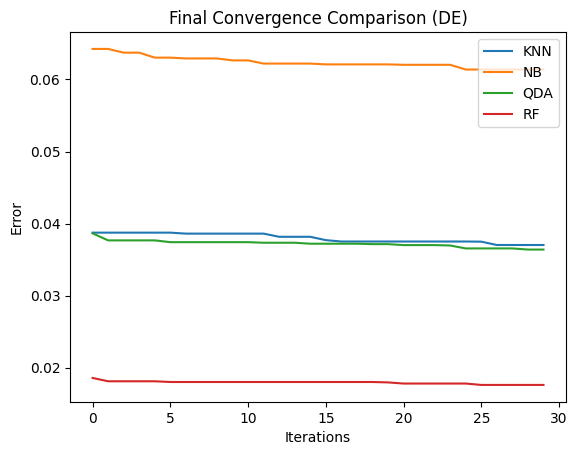


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 96.09%
Precision : 0.0167
Recall    : 0.0500
F1-Score  : 0.0250

Avg Execution Time : 8.0394 s
Avg Memory Used    : 0.0010 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  97.72%   0.0000  0.0000 0.0000      13.2    64.32%
   NB  95.45%   0.1409  0.2000 0.1648      14.6    60.54%
  QDA  97.68%   0.0000  0.0000 0.0000      13.3    64.05%
   RF  97.59%   0.0000  0.0000 0.0000      11.9    67.84%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore")

# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# =========================
# SEED
# =========================
np.random.seed(42)
random.seed(42)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-PC2.csv')

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x in ['Y', 1, True] else 0)

# =========================
# SPLIT
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

D = X_train.shape[1]

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20)
}

# =========================
# DE PARAMETERS
# =========================
NP = 10
CR = 0.9
F = 0.5
max_it = 30

# =========================
# FITNESS
# =========================
def fitness(individual, model):
    selected = np.where(individual == 1)[0]

    if len(selected) == 0:
        return 1.0

    try:
        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_train[:, selected])
        error = 1 - accuracy_score(y_train, pred)
    except:
        return 1.0

    penalty = 0.05 * (len(selected) / D)
    return error + penalty

# =========================
# INIT POPULATION
# =========================
def init_population():
    return np.random.randint(0, 2, (NP, D))

# =========================
# DE ALGORITHM
# =========================
def DE(model):

    pop = init_population()
    fit = np.array([fitness(ind, model) for ind in pop])

    convergence = []

    for _ in range(max_it):

        for i in range(NP):

            idxs = list(range(NP))
            idxs.remove(i)
            a, b, c = random.sample(idxs, 3)

            mutant = pop[a] + F * (pop[b] - pop[c])
            mutant = 1 / (1 + np.exp(-mutant))
            mutant = (mutant > np.random.rand(D)).astype(int)

            trial = pop[i].copy()

            for j in range(D):
                if random.random() < CR:
                    trial[j] = mutant[j]

            f_trial = fitness(trial, model)

            if f_trial < fit[i]:
                pop[i] = trial
                fit[i] = f_trial

        convergence.append(np.min(fit))

    best = pop[np.argmin(fit)]
    return np.where(best == 1)[0], convergence

# =========================
# MAIN LOOP
# =========================
Total_time = []
Total_memory = []

avg_acc_noFS = []
avg_prec_noFS = []
avg_rec_noFS = []
avg_f1_noFS = []

model_summaries = []

for name, model in models.items():

    print(f"\nEvaluating Model: {name}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024**2
        st = time.time()

        selected, curve = DE(model)

        et = time.time()
        mem_after = process.memory_info().rss / 1024**2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        if len(selected) == 0:
            selected = np.array([np.random.randint(0, D)])

        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_test[:, selected])

        acc = np.mean(pred == y_test)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)
        feat_list.append(len(selected))
        curves.append(curve)

        print(f"  Run {r}: Acc={acc:.4f}, Features={len(selected)}")
        print(f"  Features selected: {selected}")

    # 🔥 STORE CURVE
    model_curves[name] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model)
    clf_nofs.fit(X_train, y_train)
    pred_no = clf_nofs.predict(X_test)

    acc_no = np.mean(pred_no == y_test) * 100
    print(f"  Accuracy without FS: {acc_no:.2f}%")

    avg_acc_noFS.append(acc_no)
    avg_prec_noFS.append(precision_score(y_test, pred_no, zero_division=0))
    avg_rec_noFS.append(recall_score(y_test, pred_no, zero_division=0))
    avg_f1_noFS.append(f1_score(y_test, pred_no, zero_division=0))

    model_summaries.append({
        "Model": name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (DE)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print("\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(avg_acc_noFS):.2f}%")
print(f"Precision : {np.mean(avg_prec_noFS):.4f}")
print(f"Recall    : {np.mean(avg_rec_noFS):.4f}")
print(f"F1-Score  : {np.mean(avg_f1_noFS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.8580, Features=14
  Features selected: [ 1  5  6  9 10 12 14 17 18 21 29 30 35 37]
  Run 2: Acc=0.8765, Features=19
  Features selected: [ 1  2  3  8  9 10 15 17 20 21 22 24 25 27 28 30 32 33 35]
  Run 3: Acc=0.8951, Features=23
  Features selected: [ 1  2  4  6  9 10 11 13 14 17 19 20 21 22 24 25 26 27 28 29 31 33 37]
  Run 4: Acc=0.8735, Features=14
  Features selected: [ 0  1  6 10 11 13 15 18 22 23 27 31 33 37]
  Run 5: Acc=0.8704, Features=17
  Features selected: [ 1  3  4  6  7  8 10 14 17 19 22 24 25 27 32 33 35]
  Run 6: Acc=0.8858, Features=19
  Features selected: [ 1  2  4  6  8 10 13 14 15 17 18 21 26 27 31 32 33 34 37]
  Run 7: Acc=0.8519, Features=16
  Features selected: [ 1  3  6 10 11 12 14 16 17 18 20 24 26 28 30 34]
  Run 8: Acc=0.8827, Features=13
  Features selected: [ 0  8 10 14 15 20 23 26 27 33 34 35 37]
  Run 9: Acc=0.8704, Features=16
  Features selected: [ 1  2  4  6  8 10 11 13 19 20 21 23 24 28 31 32]
  Run 10: Acc=0.8642

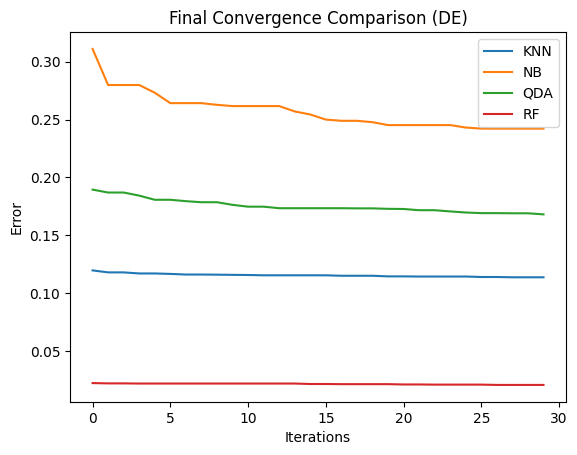


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 70.29%
Precision : 0.3938
Recall    : 0.5375
F1-Score  : 0.3126

Avg Execution Time : 14.3406 s
Avg Memory Used    : 0.0025 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  87.28%   0.4771  0.1525 0.2285      16.7    56.05%
   NB  79.97%   0.3388  0.6425 0.4428      15.6    58.95%
  QDA  86.02%   0.4341  0.4125 0.4201      19.1    49.74%
   RF  87.96%   0.5460  0.1225 0.1973      13.7    63.95%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore")

# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# =========================
# SEED
# =========================
np.random.seed(42)
random.seed(42)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-PC3.csv')

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x in ['Y', 1, True] else 0)

# =========================
# SPLIT
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

D = X_train.shape[1]

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20)
}

# =========================
# DE PARAMETERS
# =========================
NP = 10
CR = 0.9
F = 0.5
max_it = 30

# =========================
# FITNESS
# =========================
def fitness(individual, model):
    selected = np.where(individual == 1)[0]

    if len(selected) == 0:
        return 1.0

    try:
        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_train[:, selected])
        error = 1 - accuracy_score(y_train, pred)
    except:
        return 1.0

    penalty = 0.05 * (len(selected) / D)
    return error + penalty

# =========================
# INIT POPULATION
# =========================
def init_population():
    return np.random.randint(0, 2, (NP, D))

# =========================
# DE ALGORITHM
# =========================
def DE(model):

    pop = init_population()
    fit = np.array([fitness(ind, model) for ind in pop])

    convergence = []

    for _ in range(max_it):

        for i in range(NP):

            idxs = list(range(NP))
            idxs.remove(i)
            a, b, c = random.sample(idxs, 3)

            mutant = pop[a] + F * (pop[b] - pop[c])
            mutant = 1 / (1 + np.exp(-mutant))
            mutant = (mutant > np.random.rand(D)).astype(int)

            trial = pop[i].copy()

            for j in range(D):
                if random.random() < CR:
                    trial[j] = mutant[j]

            f_trial = fitness(trial, model)

            if f_trial < fit[i]:
                pop[i] = trial
                fit[i] = f_trial

        convergence.append(np.min(fit))

    best = pop[np.argmin(fit)]
    return np.where(best == 1)[0], convergence

# =========================
# MAIN LOOP
# =========================
Total_time = []
Total_memory = []

avg_acc_noFS = []
avg_prec_noFS = []
avg_rec_noFS = []
avg_f1_noFS = []

model_summaries = []

for name, model in models.items():

    print(f"\nEvaluating Model: {name}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024**2
        st = time.time()

        selected, curve = DE(model)

        et = time.time()
        mem_after = process.memory_info().rss / 1024**2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        if len(selected) == 0:
            selected = np.array([np.random.randint(0, D)])

        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_test[:, selected])

        acc = np.mean(pred == y_test)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)
        feat_list.append(len(selected))
        curves.append(curve)

        print(f"  Run {r}: Acc={acc:.4f}, Features={len(selected)}")
        print(f"  Features selected: {selected}")

    # 🔥 STORE CURVE
    model_curves[name] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model)
    clf_nofs.fit(X_train, y_train)
    pred_no = clf_nofs.predict(X_test)

    acc_no = np.mean(pred_no == y_test) * 100
    print(f"  Accuracy without FS: {acc_no:.2f}%")

    avg_acc_noFS.append(acc_no)
    avg_prec_noFS.append(precision_score(y_test, pred_no, zero_division=0))
    avg_rec_noFS.append(recall_score(y_test, pred_no, zero_division=0))
    avg_f1_noFS.append(f1_score(y_test, pred_no, zero_division=0))

    model_summaries.append({
        "Model": name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (DE)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print("\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(avg_acc_noFS):.2f}%")
print(f"Precision : {np.mean(avg_prec_noFS):.4f}")
print(f"Recall    : {np.mean(avg_rec_noFS):.4f}")
print(f"F1-Score  : {np.mean(avg_f1_noFS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.8941, Features=17
  Features selected: [ 1  2  3  4  5  8 10 11 16 17 19 21 22 27 28 31 36]
  Run 2: Acc=0.8527, Features=17
  Features selected: [ 0  2  4  8  9 10 13 14 18 22 23 28 30 31 32 35 36]
  Run 3: Acc=0.8786, Features=18
  Features selected: [ 1  2  3  4  5  7 10 15 16 19 21 22 24 26 28 31 33 35]
  Run 4: Acc=0.8992, Features=16
  Features selected: [ 0  3  4  5  8 10 14 18 19 23 25 26 27 28 33 36]
  Run 5: Acc=0.8760, Features=17
  Features selected: [ 0  3  4  6  7 12 14 16 22 23 24 25 30 32 33 35 36]
  Run 6: Acc=0.8941, Features=18
  Features selected: [ 2  3  4  5  7  8 10 12 14 15 18 19 21 23 29 33 35 37]
  Run 7: Acc=0.8786, Features=17
  Features selected: [ 3  4  5  8  9 11 12 14 15 18 21 22 26 27 29 31 32]
  Run 8: Acc=0.8889, Features=17
  Features selected: [ 1  4  5  7  9 11 14 15 19 22 24 27 28 30 31 33 34]
  Run 9: Acc=0.8837, Features=22
  Features selected: [ 1  3  4  5  7  8 10 11 13 14 15 19 23 24 25 26 29 30 31 33 34 

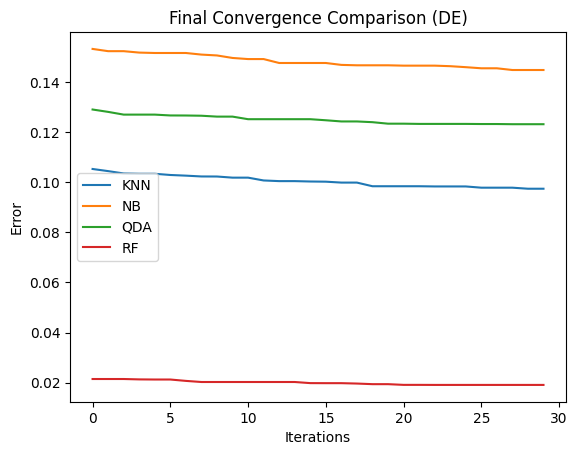


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 87.40%
Precision : 0.5758
Recall    : 0.3538
F1-Score  : 0.4251

Avg Execution Time : 14.8572 s
Avg Memory Used    : 0.0032 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  88.45%   0.6161  0.4264 0.5019      18.1    52.37%
   NB  88.19%   0.6167  0.3660 0.4541      18.7    50.79%
  QDA  90.31%   0.7455  0.4453 0.5565      23.3    38.68%
   RF  87.26%   0.5580  0.2491 0.3352      13.1    65.53%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore")

# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# =========================
# SEED
# =========================
np.random.seed(42)
random.seed(42)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-PC4.csv')

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x in ['Y', 1, True] else 0)

# =========================
# SPLIT
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

D = X_train.shape[1]

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20)
}

# =========================
# DE PARAMETERS
# =========================
NP = 10
CR = 0.9
F = 0.5
max_it = 30

# =========================
# FITNESS
# =========================
def fitness(individual, model):
    selected = np.where(individual == 1)[0]

    if len(selected) == 0:
        return 1.0

    try:
        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_train[:, selected])
        error = 1 - accuracy_score(y_train, pred)
    except:
        return 1.0

    penalty = 0.05 * (len(selected) / D)
    return error + penalty

# =========================
# INIT POPULATION
# =========================
def init_population():
    return np.random.randint(0, 2, (NP, D))

# =========================
# DE ALGORITHM
# =========================
def DE(model):

    pop = init_population()
    fit = np.array([fitness(ind, model) for ind in pop])

    convergence = []

    for _ in range(max_it):

        for i in range(NP):

            idxs = list(range(NP))
            idxs.remove(i)
            a, b, c = random.sample(idxs, 3)

            mutant = pop[a] + F * (pop[b] - pop[c])
            mutant = 1 / (1 + np.exp(-mutant))
            mutant = (mutant > np.random.rand(D)).astype(int)

            trial = pop[i].copy()

            for j in range(D):
                if random.random() < CR:
                    trial[j] = mutant[j]

            f_trial = fitness(trial, model)

            if f_trial < fit[i]:
                pop[i] = trial
                fit[i] = f_trial

        convergence.append(np.min(fit))

    best = pop[np.argmin(fit)]
    return np.where(best == 1)[0], convergence

# =========================
# MAIN LOOP
# =========================
Total_time = []
Total_memory = []

avg_acc_noFS = []
avg_prec_noFS = []
avg_rec_noFS = []
avg_f1_noFS = []

model_summaries = []

for name, model in models.items():

    print(f"\nEvaluating Model: {name}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024**2
        st = time.time()

        selected, curve = DE(model)

        et = time.time()
        mem_after = process.memory_info().rss / 1024**2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        if len(selected) == 0:
            selected = np.array([np.random.randint(0, D)])

        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_test[:, selected])

        acc = np.mean(pred == y_test)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)
        feat_list.append(len(selected))
        curves.append(curve)

        print(f"  Run {r}: Acc={acc:.4f}, Features={len(selected)}")
        print(f"  Features selected: {selected}")

    # 🔥 STORE CURVE
    model_curves[name] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model)
    clf_nofs.fit(X_train, y_train)
    pred_no = clf_nofs.predict(X_test)

    acc_no = np.mean(pred_no == y_test) * 100
    print(f"  Accuracy without FS: {acc_no:.2f}%")

    avg_acc_noFS.append(acc_no)
    avg_prec_noFS.append(precision_score(y_test, pred_no, zero_division=0))
    avg_rec_noFS.append(recall_score(y_test, pred_no, zero_division=0))
    avg_f1_noFS.append(f1_score(y_test, pred_no, zero_division=0))

    model_summaries.append({
        "Model": name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (DE)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print("\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(avg_acc_noFS):.2f}%")
print(f"Precision : {np.mean(avg_prec_noFS):.4f}")
print(f"Recall    : {np.mean(avg_rec_noFS):.4f}")
print(f"F1-Score  : {np.mean(avg_f1_noFS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)


Evaluating Model: KNN
  Run 1: Acc=0.7393, Features=20
  Features selected: [ 1  2  3  5  6  7  8  9 10 11 14 16 18 21 23 24 27 30 35 38]
  Run 2: Acc=0.7607, Features=21
  Features selected: [ 1  2  3  4  5  8 12 14 16 17 18 20 23 27 28 30 31 32 33 34 35]
  Run 3: Acc=0.7237, Features=17
  Features selected: [ 2  5  7  8 11 12 14 16 17 18 23 26 28 31 32 37 38]
  Run 4: Acc=0.7490, Features=23
  Features selected: [ 0  3  5  7  8  9 10 11 13 15 16 17 18 22 23 24 28 29 30 32 33 36 37]
  Run 5: Acc=0.7724, Features=22
  Features selected: [ 1  2  3  4  5  8 10 13 14 15 16 18 22 23 27 28 31 32 33 34 35 36]
  Run 6: Acc=0.7412, Features=19
  Features selected: [ 1  2  3  4  5  6  7  8 10 16 18 20 21 22 24 26 27 32 33]
  Run 7: Acc=0.7412, Features=25
  Features selected: [ 3  4  5  6  8  9 10 12 13 14 16 17 18 20 22 25 27 28 29 30 31 33 34 35
 36]
  Run 8: Acc=0.7549, Features=22
  Features selected: [ 2  3  4  5  7 13 15 16 17 18 20 21 23 24 25 27 28 31 33 34 35 38]
  Run 9: Acc=0.7198, 

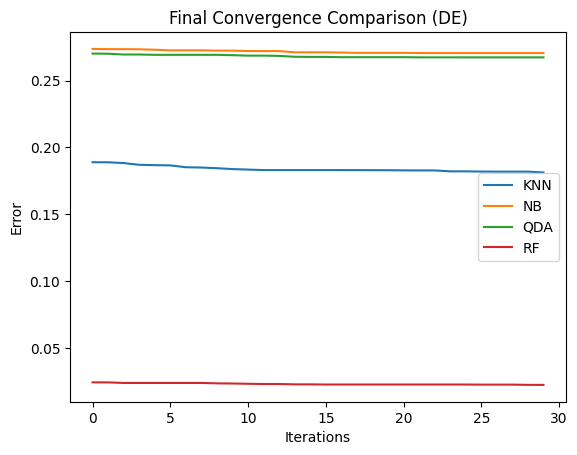


SUMMARY (averaged over 10 runs)

--- Without Feature Selection ---
Accuracy  : 75.34%
Precision : 0.5986
Recall    : 0.3014
F1-Score  : 0.3932

Avg Execution Time : 20.0534 s
Avg Memory Used    : 0.0039 MB

Model Avg Acc Avg Prec Avg Rec Avg F1 Avg Feats Reduction
  KNN  74.34%   0.5396  0.4390 0.4833      20.1    48.46%
   NB  73.95%   0.5659  0.2177 0.3143      15.8    59.49%
  QDA  74.16%   0.5812  0.2099 0.3082      16.1    58.72%
   RF  75.86%   0.5903  0.3943 0.4719      15.0    61.54%


In [ ]:
import pandas as pd
import numpy as np
import random
import time
import psutil
import os
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore")

# =========================
# 🔥 STORE CURVES
# =========================
model_curves = {}

# =========================
# SEED
# =========================
np.random.seed(42)
random.seed(42)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/DATASETS/csv_result-PC5.csv')

X = df.iloc[:, :-1]
y = df.iloc[:, -1].apply(lambda x: 1 if x in ['Y', 1, True] else 0)

# =========================
# SPLIT
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

D = X_train.shape[1]

# =========================
# MODELS
# =========================
models = {
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "RF": RandomForestClassifier(n_estimators=20)
}

# =========================
# DE PARAMETERS
# =========================
NP = 10
CR = 0.9
F = 0.5
max_it = 30

# =========================
# FITNESS
# =========================
def fitness(individual, model):
    selected = np.where(individual == 1)[0]

    if len(selected) == 0:
        return 1.0

    try:
        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_train[:, selected])
        error = 1 - accuracy_score(y_train, pred)
    except:
        return 1.0

    penalty = 0.05 * (len(selected) / D)
    return error + penalty

# =========================
# INIT POPULATION
# =========================
def init_population():
    return np.random.randint(0, 2, (NP, D))

# =========================
# DE ALGORITHM
# =========================
def DE(model):

    pop = init_population()
    fit = np.array([fitness(ind, model) for ind in pop])

    convergence = []

    for _ in range(max_it):

        for i in range(NP):

            idxs = list(range(NP))
            idxs.remove(i)
            a, b, c = random.sample(idxs, 3)

            mutant = pop[a] + F * (pop[b] - pop[c])
            mutant = 1 / (1 + np.exp(-mutant))
            mutant = (mutant > np.random.rand(D)).astype(int)

            trial = pop[i].copy()

            for j in range(D):
                if random.random() < CR:
                    trial[j] = mutant[j]

            f_trial = fitness(trial, model)

            if f_trial < fit[i]:
                pop[i] = trial
                fit[i] = f_trial

        convergence.append(np.min(fit))

    best = pop[np.argmin(fit)]
    return np.where(best == 1)[0], convergence

# =========================
# MAIN LOOP
# =========================
Total_time = []
Total_memory = []

avg_acc_noFS = []
avg_prec_noFS = []
avg_rec_noFS = []
avg_f1_noFS = []

model_summaries = []

for name, model in models.items():

    print(f"\nEvaluating Model: {name}")

    acc_list, prec_list, rec_list, f1_list, feat_list, curves = [], [], [], [], [], []

    for r in range(1, 11):

        process = psutil.Process(os.getpid())
        mem_before = process.memory_info().rss / 1024**2
        st = time.time()

        selected, curve = DE(model)

        et = time.time()
        mem_after = process.memory_info().rss / 1024**2

        Total_time.append(et - st)
        Total_memory.append(mem_after - mem_before)

        if len(selected) == 0:
            selected = np.array([np.random.randint(0, D)])

        clf = clone(model)
        clf.fit(X_train[:, selected], y_train)
        pred = clf.predict(X_test[:, selected])

        acc = np.mean(pred == y_test)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)
        feat_list.append(len(selected))
        curves.append(curve)

        print(f"  Run {r}: Acc={acc:.4f}, Features={len(selected)}")
        print(f"  Features selected: {selected}")

    # 🔥 STORE CURVE
    model_curves[name] = np.mean(curves, axis=0)

    # WITHOUT FS
    clf_nofs = clone(model)
    clf_nofs.fit(X_train, y_train)
    pred_no = clf_nofs.predict(X_test)

    acc_no = np.mean(pred_no == y_test) * 100
    print(f"  Accuracy without FS: {acc_no:.2f}%")

    avg_acc_noFS.append(acc_no)
    avg_prec_noFS.append(precision_score(y_test, pred_no, zero_division=0))
    avg_rec_noFS.append(recall_score(y_test, pred_no, zero_division=0))
    avg_f1_noFS.append(f1_score(y_test, pred_no, zero_division=0))

    model_summaries.append({
        "Model": name,
        "Avg Acc": f"{np.mean(acc_list)*100:.2f}%",
        "Avg Prec": f"{np.mean(prec_list):.4f}",
        "Avg Rec": f"{np.mean(rec_list):.4f}",
        "Avg F1": f"{np.mean(f1_list):.4f}",
        "Avg Feats": f"{np.mean(feat_list):.1f}",
        "Reduction": f"{(1 - (np.mean(feat_list)/D))*100:.2f}%"
    })

# =========================
# 🔥 FINAL GRAPH FIRST
# =========================
plt.figure()

for model_name_, curve in model_curves.items():
    plt.plot(curve, label=model_name_)

plt.title("Final Convergence Comparison (DE)")
plt.xlabel("Iterations")
plt.ylabel("Error")
plt.legend()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*55)
print("SUMMARY (averaged over 10 runs)")
print("="*55)

print("\n--- Without Feature Selection ---")
print(f"Accuracy  : {np.mean(avg_acc_noFS):.2f}%")
print(f"Precision : {np.mean(avg_prec_noFS):.4f}")
print(f"Recall    : {np.mean(avg_rec_noFS):.4f}")
print(f"F1-Score  : {np.mean(avg_f1_noFS):.4f}")

print(f"\nAvg Execution Time : {np.mean(Total_time):.4f} s")
print(f"Avg Memory Used    : {np.mean(Total_memory):.4f} MB")

print("\n" + "="*85)
print(pd.DataFrame(model_summaries).to_string(index=False))
print("="*85)